# Перминов Игорь МКТ

In [8]:
import numpy as np
import matplotlib.pyplot as plt

In [9]:
# Функции активации
def identity(x):
    return x

def step_function(x):
    return np.where(x >= 0, 1, 0)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def arctan(x):
    return np.arctan(x)

# Перцептрон
def perceptron(X, w, b, activation):
    z = np.dot(X, w) + b
    return activation(z)

In [10]:
# Генерация данных
np.random.seed(45)
class_0 = np.random.randn(50, 2) - 1
class_1 = np.random.randn(50, 2) + 1
X = np.vstack((class_0, class_1))
y = np.array([0]*50 + [1]*50)

In [11]:
# Веса и смещение
w = np.array([1.0, 1.0])
b = 0.0

In [12]:
outputs = {
    "identity": perceptron(X, w, b, identity),
    "step": perceptron(X, w, b, step_function),
    "sigmoid": perceptron(X, w, b, sigmoid),
    "tanh": perceptron(X, w, b, tanh),
    "arctan": perceptron(X, w, b, arctan),
}

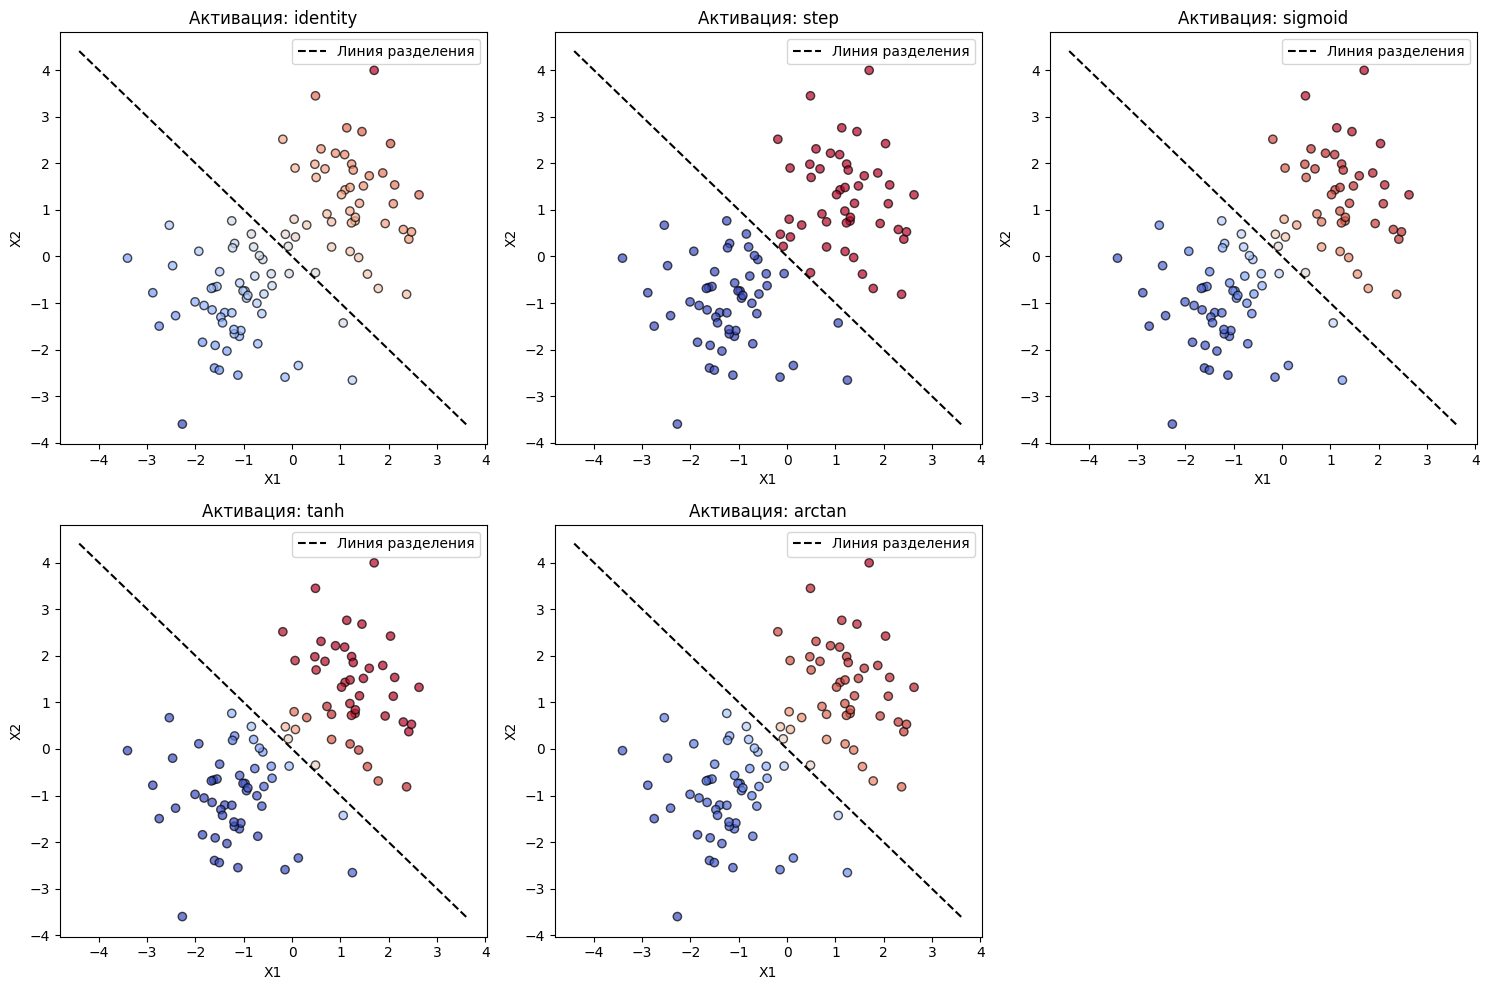

In [13]:
# Построение графиков
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

x_vals = np.linspace(min(X[:,0]) - 1, max(X[:,0]) + 1, 200)
# Вычисляем x2 по уравнению линии: w1*x1 + w2*x2 + b = 0 => x2 = -(w1*x1 + b)/w2
line_y = -(w[0]*x_vals + b)/w[1]

for i, (name, output) in enumerate(outputs.items()):
    ax = axes[i]
    scatter = ax.scatter(X[:, 0], X[:, 1], c=output, cmap='coolwarm', edgecolors='k', alpha=0.7)
    ax.plot(x_vals, line_y, 'k--', label='Линия разделения')
    ax.set_title(f"Активация: {name}")
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    ax.legend()

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

* Графики с плавными функциями активации показывают градации вероятностей или степеней активации, а не просто «да/нет». Это даёт большую информативность.
* Жёсткие функции дают отчётливую цветовую границу, но мало показывают промежуточных состояний модели.

1. **Что делает функция активации в искусственном нейроне?**
Функция активации определяет выход нейрона на основе входных данных — она преобразует взвешенную сумму входов с смещением в выходное значение. Это позволяет вносить в модель нелинейность, благодаря которой нейронные сети могут моделировать сложные, не линейно разделимые зависимости. Без функции активации нейрон ведет себя как линейный регрессор и не может решать задачи классификации с нелинейными границами.

2. **Чем отличается искусственный нейрон от однослойного перцептрона?**
Искусственный нейрон — это базовый элемент, который принимает входы, суммирует их с весами, применяет функцию активации и выдает выход. Однослойный перцептрон — это сеть из нескольких таких нейронов (часто всего один слой), используемая для классификации, где каждый нейрон решает задачу линейного разделения классов.

3. **Какое правило используется для обучения перцептрона?**
Классическое правило — правило Хебба и его вариант для перцептрона: веса обновляются пропорционально ошибке между истинным и предсказанным значением, умноженной на вход. Формула:
$$
w := w + \eta (y_{\text{true}} - y_{\text{pred}}) x
$$
где $$\eta$$ — скорость обучения.

4. **Почему однослойный перцептрон не может решить задачу XOR?**
Потому что задача XOR является нелинейно разделимой: нельзя провести одну прямую, которая разделит классы XOR на плоскости. Однослойный перцептрон может построить только линейные разделяющие границы.

5. **Что произойдет, если изменить функцию активации с сигмоиды на ReLU?**
ReLU (Rectified Linear Unit) обнуляет отрицательные значения и оставляет положительные без изменений, ускоряя обучение за счет уменьшения эффекта затухающих градиентов, свойственного сигмоиде. При этом ReLU позволяет более эффективно обучать глубокие сети и улучшает сходимость, но может привести к «умиранию» нейронов, если их выход постоянно отрицателен.